Benjamin Arnold; 09/13/2026; Lab 3-- Oscillator Simulation.

Part A-- The Simple Harmonic Oscillator

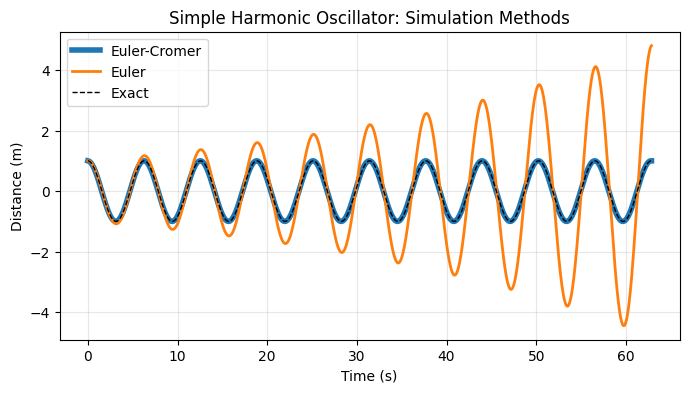

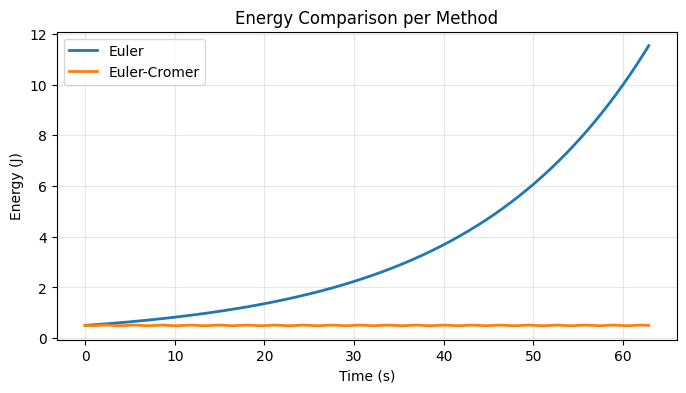

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

time_step=0.05
v0=0.0
x0=1.0

m=1.0
k=1.0
b=0.2
F0=1.0

omega0=np.sqrt(k/m)
T=2*np.pi/omega0

def exact_x(t):
    return x0*np.cos(omega0*t)

def simulate_sho(method,dt,n_periods):
    v=v0
    x,t=x0,0.0

    KE=(0.5*m)*v**2
    PE=0.5*k*x**2
    E=KE+PE
    
    t_arr,x_arr,v_arr,E_arr=[t],[x],[v],[E]

    t_max=T*n_periods
    while (t<=t_max):
        if (method==1):
            a=-(k*x)/m
            v=v+a*dt
            x=x+v*dt
        elif(method==0):
            a=-(k*x)/m
            x=x+v*dt
            v=v+a*dt
            

        KE=(0.5*m)*v**2
        PE=0.5*k*x**2
        E=KE+PE

        t=t+dt

        t_arr.append(t)
        x_arr.append(x)
        v_arr.append(v)
        E_arr.append(E)
    return t_arr,x_arr,v_arr,E_arr

t1,x1,v1,E1=simulate_sho(1,0.05,10)
t,x,v,E=simulate_sho(0,0.05,10)

t_exact=np.linspace(0, 10*T, 2000)
x_exact=exact_x(t_exact)

plt.figure(figsize=(8, 4))
plt.plot(t1, x1, linewidth=4, label='Euler-Cromer')
plt.plot(t, x, linewidth=2, label='Euler')
plt.plot(t_exact, x_exact,'k--' ,linewidth=1, label='Exact')
plt.xlabel('Time (s)')
plt.ylabel('Distance (m)')
plt.title('Simple Harmonic Oscillator: Simulation Methods')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, E, linewidth=2, label='Euler')
plt.plot(t1, E1, linewidth=2, label='Euler-Cromer')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Energy Comparison per Method')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Notes: Over ten periods, the Euler method has its amplitude grow by more the fourfold. The energy for the Euler method grows over tenfold in ten periods. The Euler-Cromer method, by contrast, wobbles about the same energy from beginning to end of the simulation.

Part B-- Phase Space & Damped Oscillations

B.1-- Phase-space Portraits

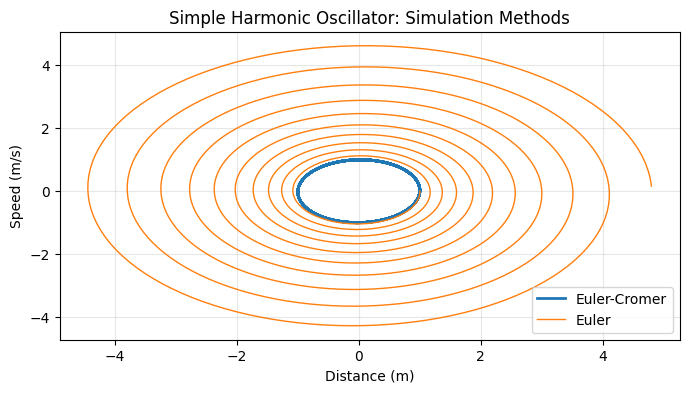

In [15]:
t1,x1,v1,E1=simulate_sho(1,0.05,10)
t,x,v,E=simulate_sho(0,0.05,10)

plt.figure(figsize=(8, 4))
plt.plot(x1, v1, linewidth=2, label='Euler-Cromer')
plt.plot(x, v, linewidth=1, label='Euler')
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.title('Simple Harmonic Oscillator: Simulation Methods')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Notes: In the phase portrait, the Euler method spirals outward to infinity, whereas the Euler-Cromer method stays stuck in a loop. This mirrors how energy is conserved for Euler-Cromer but diverges for Euler. Essentially, for EC the distance travelled and the speed gained is always trapped within a certain set of possibilities acquired by initial conditions, but for Euler, these possibilities expand over time.

B.2-- Add Damping

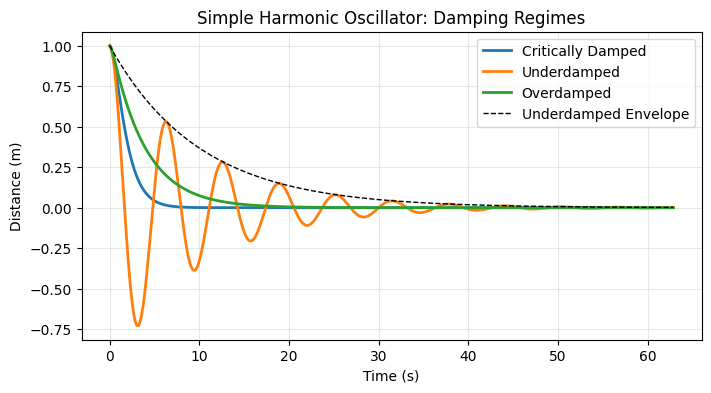

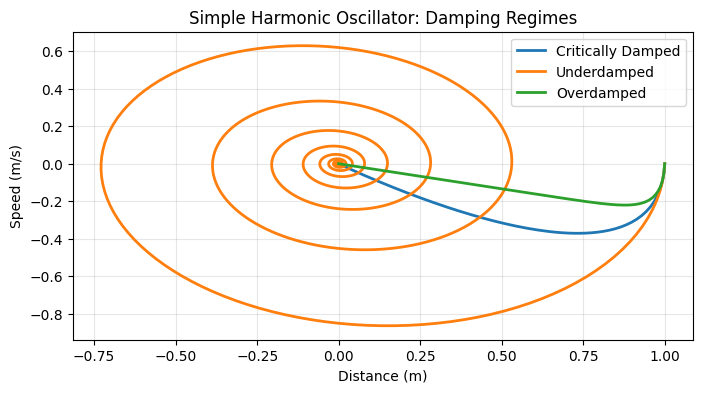

In [ ]:
def decay_env(t,b):
    return x0*np.e**(-(b/(2*m))*t)

def simulate_sho_damp(method,dt,n_periods,b):
    v=v0
    x,t=x0,0.0

    KE=(0.5*m)*v**2
    PE=0.5*k*x**2
    E=KE+PE
    
    t_arr,x_arr,v_arr,E_arr=[t],[x],[v],[E]

    t_max=T*n_periods
    while (t<=t_max):
        if (method==1):
            a=-(k*x)/m-(b/m)*v
            v=v+a*dt
            x=x+v*dt
        elif(method==0):
            a=-(k*x)/m-(b/m)*v
            x=x+v*dt
            v=v+a*dt
            

        KE=(0.5*m)*v**2
        PE=0.5*k*x**2
        E=KE+PE

        t=t+dt

        t_arr.append(t)
        x_arr.append(x)
        v_arr.append(v)
        E_arr.append(E)
    return t_arr,x_arr,v_arr,E_arr

tc,xc,vc,Ec=simulate_sho_damp(1,0.05,10,2)
to,xo,vo,Eo=simulate_sho_damp(1,0.05,10,4)
tu,xu,vu,Eu=simulate_sho_damp(1,0.05,10,0.2)

t_exact=np.linspace(0, 10*T, 2000)
xu_exact=decay_env(t_exact,0.2)

plt.figure(figsize=(8, 4))
plt.plot(tc, xc, linewidth=2, label='Critically Damped')
plt.plot(tu, xu, linewidth=2, label='Underdamped')
plt.plot(to, xo, linewidth=2, label='Overdamped')
plt.plot(t_exact, xu_exact,'k--' ,linewidth=1, label='Underdamped Envelope')
plt.xlabel('Time (s)')
plt.ylabel('Distance (m)')
plt.title('Simple Harmonic Oscillator: Damping Regimes')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(xc, vc, linewidth=2, label='Critically Damped')
plt.plot(xu, vu, linewidth=2, label='Underdamped')
plt.plot(xo, vo, linewidth=2, label='Overdamped')
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.title('Simple Harmonic Oscillator: Damping Regimes')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Note: In the phase diagram, we see that only the underdamped oscillator actually undergoes oscillations proper. The critical and overdamped oscillators both go quickly to the origin (to rest). Of course, the overdamped looks harsher in the phase diagram, but the x vs t plot shows us that critical damping is actually taking the shortest path to rest, which is interesting to note.

Part C-- Driven Oscillations and Resonance

In [ ]:
def simulate_sho_driven(method,dt,n_periods,omegad):
    v=v0
    x,t=x0,0.0

    KE=(0.5*m)*v**2
    PE=0.5*k*x**2
    E=KE+PE
    
    t_arr,x_arr,v_arr,E_arr=[t],[x],[v],[E]

    t_max=T*n_periods
    while (t<=t_max):
        if (method==1):
            a=-(k*x)/m-(b/m)*v
            v=v+a*dt
            x=x+v*dt
        elif(method==0):
            a=-(k*x)/m-(b/m)*v
            x=x+v*dt
            v=v+a*dt
            

        KE=(0.5*m)*v**2
        PE=0.5*k*x**2
        E=KE+PE

        t=t+dt

        t_arr.append(t)
        x_arr.append(x)
        v_arr.append(v)
        E_arr.append(E)
    return t_arr,x_arr,v_arr,E_arr